In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix


In [2]:
df = pd.read_csv('dermatology_database_1.csv')

In [3]:
df.iloc[:,0:10].head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement
0,2,2,0,3,0,0,0,0,1,0
1,3,3,3,2,1,0,0,0,1,1
2,2,1,2,3,1,3,0,3,0,0
3,2,2,2,0,0,0,0,0,3,2
4,2,3,2,2,2,2,0,2,0,0


In [4]:
df.iloc[:,10:20].head()

,family_history,melanin_incontinence,eosinophils_infiltrate,PNL_infiltrate,fibrosis_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_rete_ridges
0,0,0,0,0,0,3,2,0,0,0
1,1,0,0,1,0,1,2,0,2,2
2,0,1,0,0,0,1,2,0,2,0
3,0,0,0,3,0,0,2,0,3,2
4,0,1,0,0,0,1,2,0,0,0


In [5]:
df.iloc[:,20:30].head()

,elongation_rete_ridges,thinning_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug
0,0,0,0,0,0,0,0,3,0,0
1,2,2,2,1,0,0,0,0,0,0
2,0,0,0,0,2,0,2,3,2,0
3,2,2,2,0,0,3,0,0,0,0
4,0,0,0,0,2,2,3,2,3,0


In [6]:
df.iloc[:,30:].head()

,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,0,1,0,55,2
1,0,1,0,8,1
2,0,2,3,26,3
3,0,3,0,40,1
4,0,2,3,45,3


In [7]:
# Conclusion : Only Age is a continous numeric column
# I know the above steps look dumb (I did it anyway) , instead we could have used excel or sliding window to display each .

In [8]:
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [9]:
df.tail()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3
365,3,2,2,0,0,0,0,0,3,3,...,2,0,0,0,0,0,3,0,35,1


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   erythema                             366 non-null    int64
 1   scaling                              366 non-null    int64
 2   definite_borders                     366 non-null    int64
 3   itching                              366 non-null    int64
 4   koebner_phenomenon                   366 non-null    int64
 5   polygonal_papules                    366 non-null    int64
 6   follicular_papules                   366 non-null    int64
 7   oral_mucosal_involvement             366 non-null    int64
 8   knee_and_elbow_involvement           366 non-null    int64
 9   scalp_involvement                    366 non-null    int64
 10  family_history                       366 non-null    int64
 11  melanin_incontinence                 366 non-null    int64
 12  eosin

In [11]:
df.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [12]:
# sns.pairplot(
#     data  = df.drop(x.index).astype('int')  
# )

In [13]:
df.select_dtypes('int') # Almost all of the data is in integer form

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,0,3,0,0,0,1,0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,0,1,0,1
2,2,1,2,3,1,3,0,3,0,0,...,2,0,2,3,2,0,0,2,3,3
3,2,2,2,0,0,0,0,0,3,2,...,0,3,0,0,0,0,0,3,0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,2,3,2,3,0,0,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,2,0,4
362,3,2,1,0,1,0,0,0,0,0,...,0,1,0,1,0,0,0,2,0,4
363,3,2,2,2,3,2,0,2,0,0,...,3,0,3,0,3,0,0,2,3,3
364,2,1,3,1,2,3,0,2,0,0,...,3,0,2,0,1,0,0,2,3,3


In [14]:
df.select_dtypes('str') # Age is mistakenly a string need to explore more

,age
0,55
1,8
2,26
3,40
4,45
...,...
361,25
362,36
363,28
364,50


In [15]:
df['age'].info()

<class 'pandas.Series'>
RangeIndex: 366 entries, 0 to 365
Series name: age
Non-Null Count  Dtype
--------------  -----
366 non-null    str  
dtypes: str(1)
memory usage: 3.0 KB


In [16]:
# pd.to_numeric(df['age'],errors='raise') # there are string values merge too cause if i run this I clearly get a error

In [17]:
# pd.to_numeric(df['age'],errors='coerce',downcast='integer')

In [18]:
df[ df['age'] != df['age'].str.replace(r'[^0-9]','',regex=True) ]['age'] # Find those rows whose age was not a digit . 

33     ?
34     ?
35     ?
36     ?
262    ?
263    ?
264    ?
265    ?
Name: age, dtype: str

In [19]:
x = df[ df['age'] != df['age'].str.replace(r'[^0-9]','',regex=True) ]

In [20]:
x # These are the rows with anamolies ; need to find a way : fix or drop

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
33,2,2,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,?,1
34,2,1,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,?,4
35,2,2,1,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,?,2
36,2,1,2,3,2,3,0,2,0,0,...,0,2,0,2,0,0,0,3,?,3
262,2,1,0,2,0,0,0,0,0,0,...,0,0,2,0,0,0,3,0,?,5
263,1,1,1,3,0,0,0,0,0,0,...,0,0,3,0,0,0,2,0,?,5
264,1,1,0,2,0,0,0,0,1,0,...,0,0,2,0,0,0,3,0,?,5
265,1,1,0,3,0,0,0,0,0,0,...,0,0,2,0,0,0,3,0,?,5


In [21]:
df['age_numeric'] = pd.to_numeric(df['age'],errors='coerce',downcast='integer')

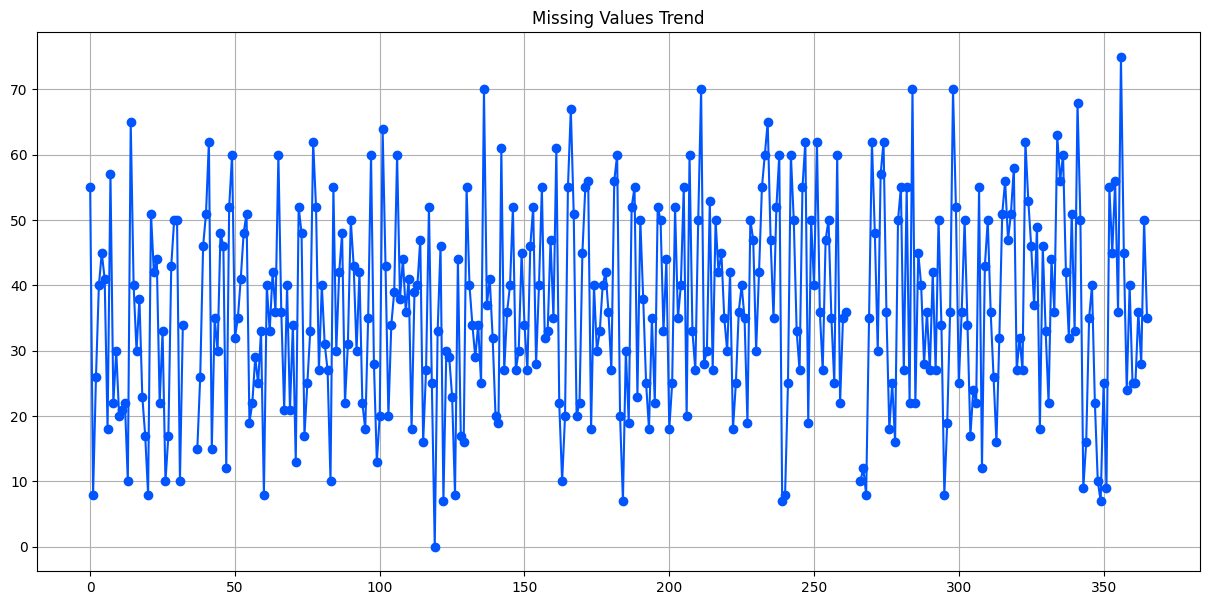

In [22]:
plt.figure(figsize=(15,7))
plt.plot(
            df.index,
            df['age_numeric'],
            marker='o',
            linestyle='-',
            linewidth=1.5,
            color="#0055FF"
)  
plt.grid(visible=0.5)
plt.title('Missing Values Trend')          
plt.show()
# If we look closely there is broken line between approximately 25 to 40 && 260 to 270 
# These are basically their errors we saw before following a trend
# Altough there is a trend we cannot use interpolation here , so we willn use median, mean or any other method.

In [23]:
df['age_numeric'].describe()

count    358.000000
mean      36.296089
std       15.324557
min        0.000000
25%       25.000000
50%       35.000000
75%       49.750000
max       75.000000
Name: age_numeric, dtype: float64

In [24]:
df['age'] = df.groupby('class')['age_numeric'].transform(lambda x : x.fillna(x.median()))
# Filling group by where we group the values according to class find theri mean and fill value for each class

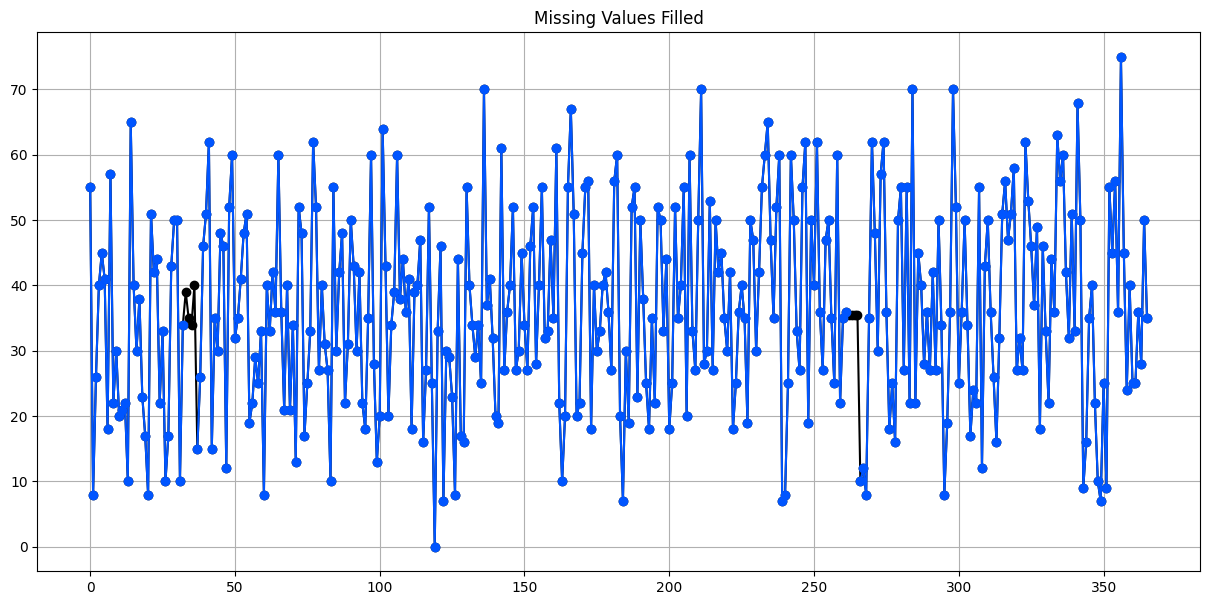

In [25]:
plt.figure(figsize=(15,7))
plt.plot(
            df.index,
            df['age'],
            marker='o',
            linestyle='-',
            linewidth=1.5,
            color="#000000"
)  
plt.plot(
            df.index,
            df['age_numeric'],
            marker='o',
            linestyle='-',
            linewidth=1.5,
            color="#0055FF"
)  
plt.grid(visible=0.5)
plt.title('Missing Values Filled')          
plt.show()
# You can clearly see that values filled were in correct order

In [26]:
df = df.drop('age_numeric',axis=1) # Drop the redundant column

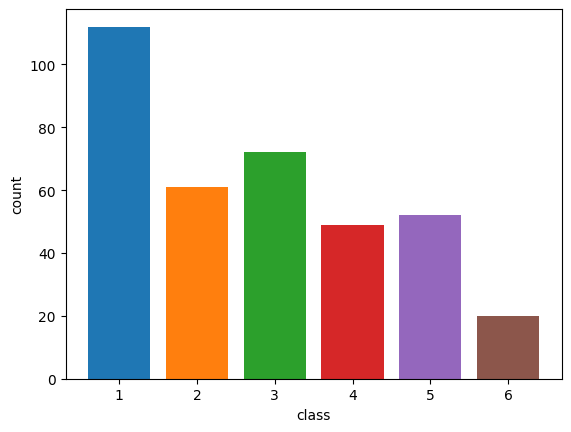

In [ ]:
sns.countplot(
                data  = df,
                x = 'class',
                hue = 'class',
                palette = 'tab10',
                stat ='count',
                saturation = 1,
                native_scale = True
)
plt.show()
# There is imbalancedness as class 1 is peaked a lot from other classes , so we make sure whenever
# we are doing train test split we stratify = y .
# Why ? To make sure the class with fewer columns dont get into one smaller set like 20 or 30 for testing . +

In [41]:
# plt.figure(figsize=(12, 6))
# sns.boxenplot(data=df, x='class', y='age',hue='class', palette='viridis')
# plt.title('Age Distribution by Class (Pre-Split Check)')
# plt.show()